#*Анализ сердечных заболеваний с использованием методов машинного обучения.*

#*Боцу Алина*



#*Данная работа создана для 2025 Blended Intensive Programme (B.I.P.) in Mathematical Modelling L'Aquila, June - July 2025.*


---
*Сердечно-сосудистые заболевания остаются одной из ведущих причин смертности во всём мире. Ранняя диагностика и своевременное лечение являются ключевыми факторами, способствующими улучшению качества жизни и снижению смертности. С развитием технологий машинного обучения стало возможным анализировать медицинские данные и выявлять закономерности, которые помогают прогнозировать наличие или отсутствие заболевания на основе биомаркеров.*

---

#Цель работы

---

Целью данной работы является :

*   применение методов машинного обучения для анализа медицинского датасета, содержащего информацию о пациентах

*   построение модели, способной предсказывать наличие сердечного заболевания на основе биомаркеров.

*   решение проблем из полученных реультатов

---

#Загрузка и первичный анализ

---
*Нам понадобится загрузить данные. Для примера мы просим вывести лишь первые 10 строчек данной базы.*

---

In [ ]:
path = "/content/drive/MyDrive/heart.csv"
data = pd.read_csv(path, sep=',')
data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


---
*Чтобы проанализировать данную базу данных мы поставили себе вопросы, на которые хотели бы получить ответы. В зависимости от вопроса мы будем использовать различные функции, методы и модели, чтобы корректро и правильно ответить на поставленные задачи*

---

# *Как возраст пациентов распределён среди больных и здоровых? Есть ли тенденция, что болезнь чаще встречается у пожилых?*

---

Построим таблицу распределения людей с заболеванием и без заболевания

---


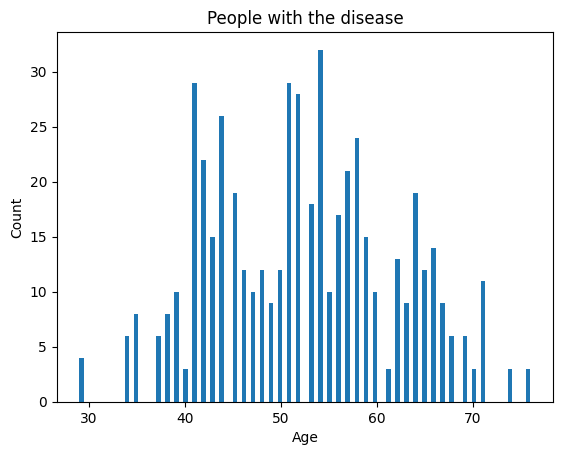


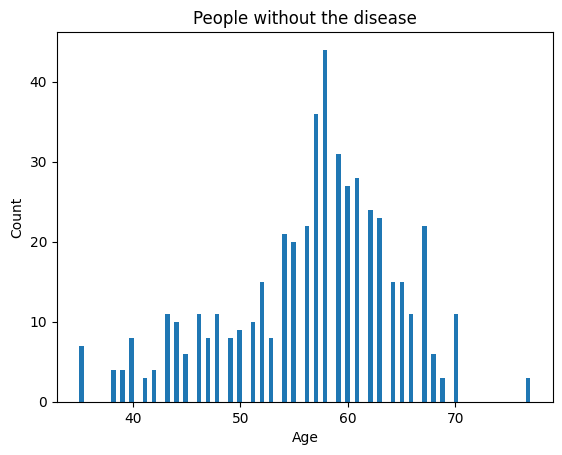

---
*Теперь можно изобразить 2 гистограммы вместе и сравнить результаты*

---

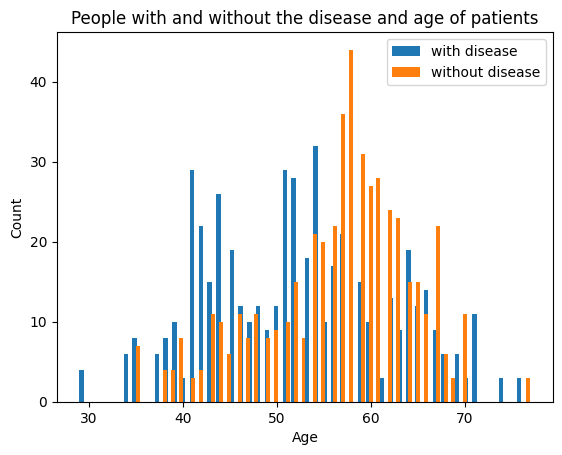

---
Смотря на этот график можно сделать вывод что:

*   возраст распределен от чуть меньше 30 до 70 и выше, а людей с заболеванием от 50 до 70 лет
*   количество людей с заболеванием  больше, нежели людей без заболевания.
*    возраст влияет на частоту заболеваний

---

#*Влияет ли пол пациента на вероятность сердечного заболевания? Чаще ли встречаются болезни сердца у мужчин или женщин?*



In [ ]:
pd.Series.corr(data["sex"], data["target"])

np.float64(-0.2795007572922625)

---
*Коэффициент корреляции -0.2795 указывает на то, что пол не влияет на вероятность заболевания.*

!!! НО !!!

*Данный вывод не может являться достоверным, так как в открытых источникаж  есть тенденция что чаще такими заболеваниями страдают мужчины, нежели женщины. Это значит что в нашей базе данным может быть не достатчное количество информации для того, чтобы проследить тенденцию, так как мужчин у нас минимум в два раза больше. Поэтому данные не являются окончательными*

---


#*Как распределяется уровень холестерина (chol) у пациентов с болезнью и без? Можно ли выделить критические уровни холестерина?*


---
*Построим график для того чтобы просмотреть распределение*

---

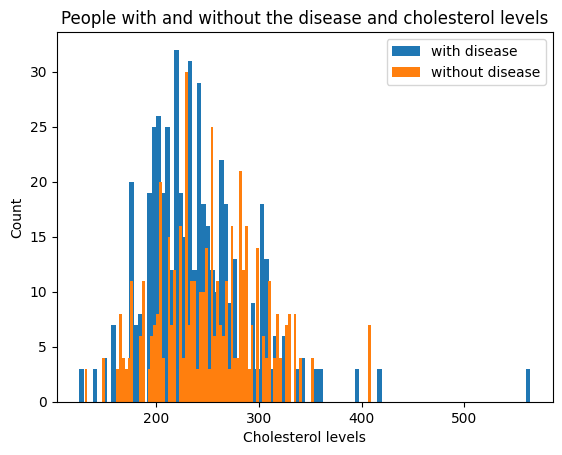

---
*Найдем критические значения*

---


In [ ]:
data["chol"].min()

126

In [ ]:
data["chol"].max()

564

---

*Уровень холестерина значительно больше у тех, кто страдает сердечными заболеваниями, в отличаи от тех, кто ими не страдает.*

*Так же минимальный критический уровень у нас это 126 мг/дл, а максимальный 564 мг/дл.*

---

#*Связан ли повышенный уровень сахара натощак (fbs) с сердечными заболеваниями?*




---
*Определим уровень корреляции между двумя показателями.*

---

In [ ]:
pd.Series.corr(data["fbs"], data["target"])

np.float64(-0.041163547464651264)

---

*Из данного результата видим, что повышенный уровень сахара не связан с сердечными заболеваниями.*

---

#*Какие признаки имеют наибольшую корреляцию с заболеванием (target)?*


---
*Чтобы это выяснить, можно сразу построить таблицу корреляции и вручную просмотреть все показатели.*

---

In [ ]:
data.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


---

*Из данной таблицы показатели ```cp, thalach, slope, restecg``` имеют наибольшую корреляцию с заблеваниями.*

---

#*Как влияют тип боли в груди (cp) и результаты ЭКГ (restecg) на вероятность заболевания?*


---
*Для того, чтобы определить влияние этих показателей, нужно построить модель Логистической регресии и найти коэффициенты модели.*

---



```
Коэффициенты модели: [[0.96062436 0.50921739]]
```



---
*После того, как мы построили модель, можно сделать вывод: эти признаки увеличивают вероятность болезни.*

*cp (тип боли в груди): сильнее всего влияет на наличие заболевания.*

*restecg (результаты ЭКГ): более слабый, но иногда значимый признак.*

---

#*Можно ли по биомаркерам (возраст, холестерин, давление, ЭКГ и т. д.) предсказать наличие сердечного заболевания?*

---

*Чтобы это определить мы должны как в прошлый раз построить модель.*

---

```
               precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205
```



---

*Отвечая на вопрос: Да, если построить правильную модель, то можно предсказавать по биомаркерам наличие сердечного заболевания, так как построеная модель показывает 80% правильности ее результата, где можно посмотреть по accuracy.*

---

#Как изменится точность модели, если нормализовать или стандартизировать признаки?


---
*Чтобы проверить, как изменится точность, мы должны проверим модель без нормализации и стандартизации наших данных, что мы делаем далее*

---

Без нормализации:

```
Without Scaling:
              precision    recall  f1-score   support

           0       0.84      0.69      0.76       102
           1       0.74      0.87      0.80       103

    accuracy                           0.78       205
   macro avg       0.79      0.78      0.78       205
weighted avg       0.79      0.78      0.78       205
```

Со стандартизацией:

```
With Standardization:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205
```

С нормализацией:



```
With MinMax Normalization:
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       102
           1       0.77      0.90      0.83       103

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205
```

---

*Обращая внимание на главный признак  accuracy мы видим результат 80% при стандартизации и 81% при нормализации, где без испоьзования этого получали 78%.*

*Это означает, что если использовать один из 2-х главных методов преобразования данных, то точность наших моделей может возрасти и соотведственно возростает эффективность модели.*

*Это крайне важно для нас, так как нам нужно делать выводы, которые напрямую зависят на жизнь человека и на постановку диагноза.*

---


#*Какое сочетание признаков даёт наилучшее качество классификации?*


```
Feature scores:
 oldpeak     243.450780
exang       242.883889
cp          238.558457
thalach     222.799538
ca          174.877078
slope       138.679393
thal        131.802996
sex          86.689707
age          56.785135
trestbps     20.087353
restecg      18.838205
chol         10.326152
fbs           1.736352
dtype: float64
```
```
top 5:
oldpeak    243.450780
exang      242.883889
cp         238.558457
thalach    222.799538
ca         174.877078
dtype: float64
```

---
*Признаки ```oldpeak, exang, cp, thalach ,ca``` и их сочетание дает наилучшее качество классификации.*

---

#*Есть ли критические значения ST-сегмента (oldpeak), при которых риск максимален?*


---
*Мы должны вывести средние значения, чтобы посмотреть с чем сравнивать больных и здоровых людей.*

---

In [ ]:
data.groupby('target')['oldpeak'].mean()

,oldpeak
target,
0,1.600200
1,0.569962


---

*Для здоровых людей если показатель значеня ST-сегомента больше 1.60, то этот риск возрастает. Аналлгично и про больных людей: если показатели превышают 	0.57, то риск возрастает.*

---




#*У каких пациентов чаще встречается заболевание: у тех, у кого изменён slope, повышен oldpeak и ca больше 0?*


---
*Чтобы это определить, мы должны выделить людей с такими признаками через определенные фильтр*

*На примере рассмотрим признак oldpeak больще или равен 0.5 (Значение взято из интернета)*

---

In [ ]:
data[data["oldpeak"]>=0.5]["target"].mean()*100

np.float64(35.738255033557046)

---
*На 35% чаще встречается заболевание у людей, если у них повышено Снижение сегмента ST при нагрузке по сравнению с покоем (oldpeak)*

---

In [ ]:
data[data["slope"]!=0]["target"].mean()*100

np.float64(52.36593059936908)

---

*На 52% чаще встречается заболевание у людей, если у них Форма ST-сегмента при нагрузке не ровняется 0 (slope)*

---

In [ ]:
data[data["ca"]>0]["target"].mean()*100

np.float64(24.832214765100673)

---

*На 24% чаще встречается заболевание у людей, если у них Количество сосудов, окрашенных при флюороскопии от 1 и выше (са)*

---

#*Какие распределения числовых признаков (age, trestbps, chol, thalach, oldpeak) наблюдаются в подгруппах пациентов с болезнью и без болезни?*


---

*Мы можем увидеть всю информацию про данные признаки и так же их распределение.*

---

In [ ]:
datatrgt1.describe()[["age", "trestbps", "chol", "thalach", "oldpeak"]]

,age,trestbps,chol,thalach,oldpeak
count,526.000000,526.000000,526.000000,526.000000,526.000000
mean,52.408745,129.245247,240.979087,158.585551,0.569962
std,9.631804,16.112188,53.010345,19.096928,0.771079
min,29.000000,94.000000,126.000000,96.000000,0.000000
25%,44.000000,120.000000,208.000000,149.000000,0.000000
50%,52.000000,130.000000,234.000000,161.500000,0.200000
75%,59.000000,140.000000,265.750000,172.000000,1.000000
max,76.000000,180.000000,564.000000,202.000000,4.200000


In [ ]:
datatrgt0.describe()[["age", "trestbps", "chol", "thalach", "oldpeak"]]

,age,trestbps,chol,thalach,oldpeak
count,499.000000,499.000000,499.000000,499.000000,499.000000
mean,56.569138,134.106212,251.292585,139.130261,1.600200
std,7.908153,18.576736,49.558924,22.565235,1.290956
min,35.000000,100.000000,131.000000,71.000000,0.000000
25%,52.000000,120.000000,217.000000,125.000000,0.600000
50%,58.000000,130.000000,249.000000,142.000000,1.400000
75%,62.000000,144.000000,284.000000,156.000000,2.500000
max,77.000000,200.000000,409.000000,195.000000,6.200000


---

*По нашему желаю мы хотим визуализировать полученные результаты.*

---


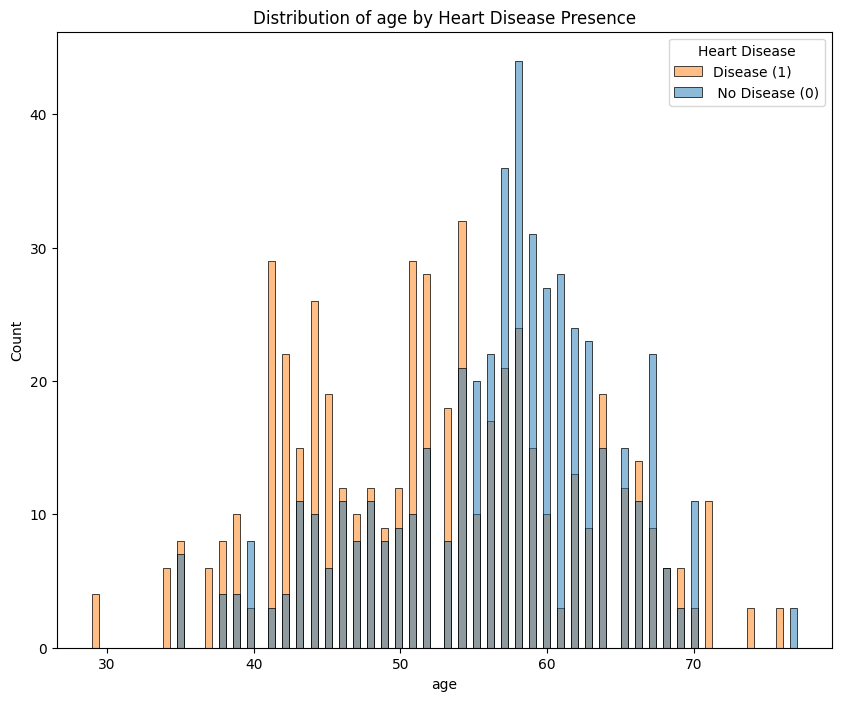

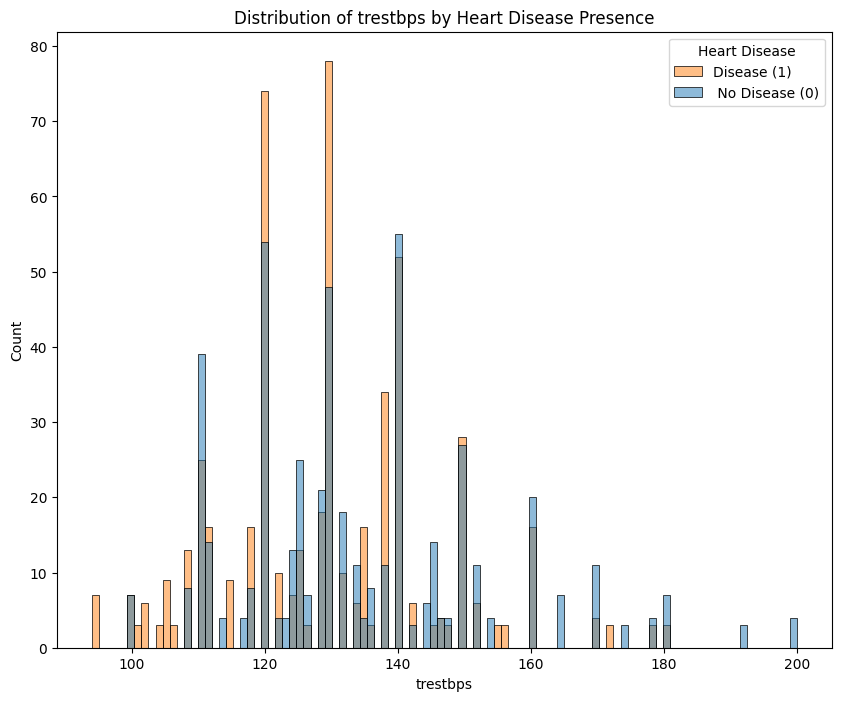

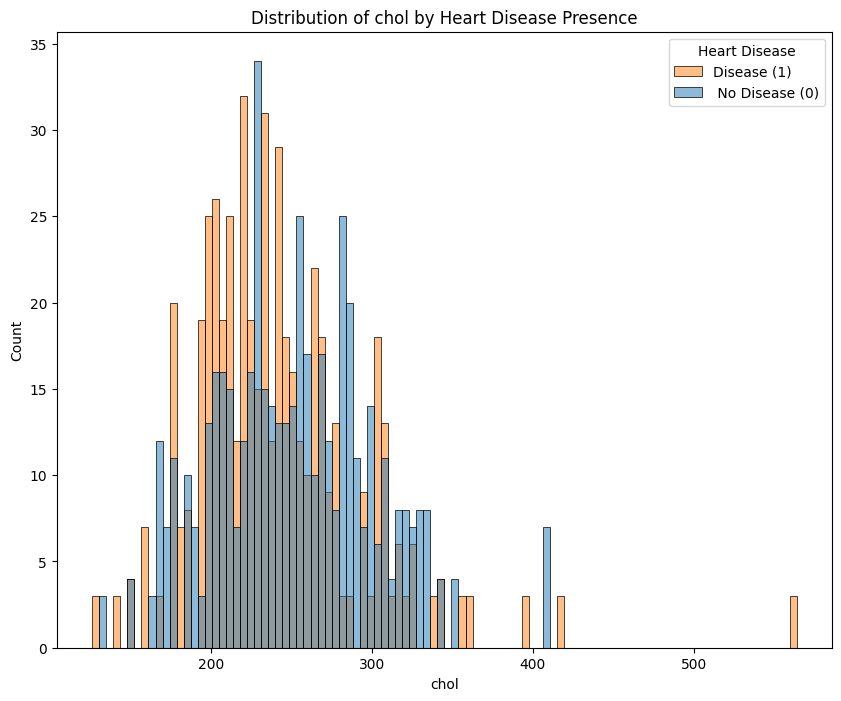

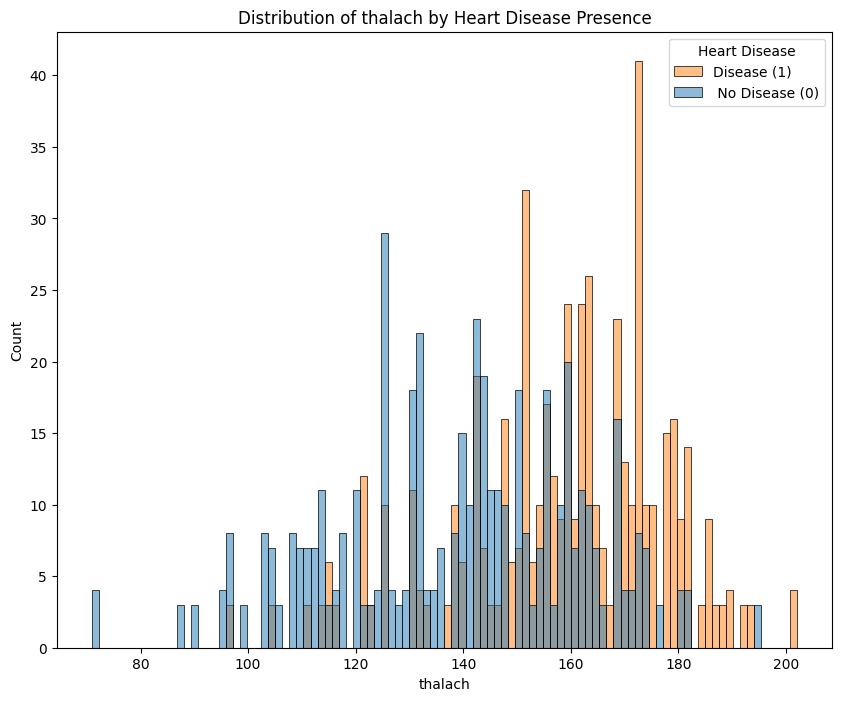

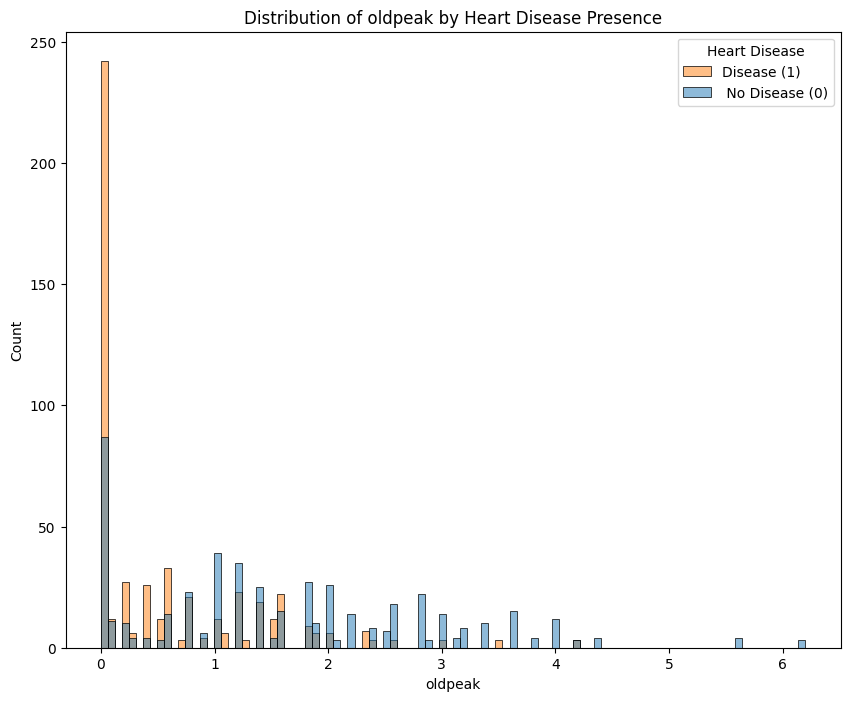

#*Mожно ли с помощью корреляции и методов отбора признаков (SelectKBest, деревья решений) выделить ключевые переменные?*


---

*В прошлый разы мы использовали SelectKBest и матрицы корреляции, в этот раз можно использовать деревья решений*

---



```
Feature importance (Decision Tree):
 cp          0.270006
ca          0.155398
oldpeak     0.100665
chol        0.088038
thal        0.080872
age         0.079670
trestbps    0.051714
thalach     0.043401
sex         0.037490
slope       0.033580
exang       0.030011
restecg     0.018727
fbs         0.010428
dtype: float64
```



---

*Дерево показывает, какие признаки модель использует в первую очередь для разделения классов.*

---

*С помощью этих всех методов отбора признаков можно выделить ключевые переменные. И если посмотреть какие переменые повторяются, можно с уверенностью сказать что эти признаки ключевые*

---

#Насколько точно модели (Logistic Regression, Decision Tree, KNN) могут предсказывать наличие болезни сердца?
#Какие метрики качества (accuracy, precision, recall, F1-score, ROC-AUC) дают лучшее представление о прогнозе?


---
*Построим уже устоявшиеся шаги для написания модели и используем модели Logistic Regression, Decision Tree, KNN*

---



```
test_size=0.2
Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205

ROC-AUC: 0.8787

Decision Tree
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

ROC-AUC: 0.9854

KNN
              precision    recall  f1-score   support

           0       0.88      0.77      0.82       102
           1       0.80      0.89      0.84       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205

ROC-AUC: 0.9486
```



---
*Модели Logistic Regression, Decision Tree, KNN могут довольно точно предсказывать наличие болезни сердца, показывая это через параметр ```roc_auc``` насколько модель хорошо различает больных и здоровых (чем ближе к 1.0, тем лучше)*


*Чтобы иметь лучшее представления о прогнозе, стоит учитывать характеристики наших метрик:*

*```аccuracy``` — общий процент верных предсказаний.*

*```рrecision``` — насколько часто модель ошибается, говоря что человек болен.*

*```recall``` — насколько часто модель правильно находит больных.*

*```f1-score``` — среднее между precision и recall.*

*```roc-auc``` — общий показатель надёжности модели.*

*В предсказаниях сердечных заболеваний особенно важны Recall, F1-score и ROC-AUC. Они помогают не пропустить больных и оценить надёжность модели.*

---

#*Как изменяется надёжность модели, если использовать разные пропорции данных для обучения и тестирования?*


---
*Для того, чтобы это проследить, будем увеличивать пропорции данных для иследования, увеличивая парамент test_size*

---




```
test_size=0.3
Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.75      0.80       159
           1       0.76      0.87      0.81       149

    accuracy                           0.81       308
   macro avg       0.81      0.81      0.80       308
weighted avg       0.81      0.81      0.80       308

ROC-AUC: 0.8968

Decision Tree
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       159
           1       1.00      0.94      0.97       149

    accuracy                           0.97       308
   macro avg       0.97      0.97      0.97       308
weighted avg       0.97      0.97      0.97       308

ROC-AUC: 0.9698

KNN
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       159
           1       0.82      0.87      0.84       149

    accuracy                           0.84       308
   macro avg       0.84      0.84      0.84       308
weighted avg       0.84      0.84      0.84       308

ROC-AUC: 0.9484
```





```
test_size=0.4
Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       202
           1       0.79      0.84      0.81       208

    accuracy                           0.81       410
   macro avg       0.81      0.81      0.81       410
weighted avg       0.81      0.81      0.81       410

ROC-AUC: 0.9029

Decision Tree
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       202
           1       1.00      0.96      0.98       208

    accuracy                           0.98       410
   macro avg       0.98      0.98      0.98       410
weighted avg       0.98      0.98      0.98       410

ROC-AUC: 0.9784

KNN
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       202
           1       0.83      0.87      0.85       208

    accuracy                           0.85       410
   macro avg       0.85      0.85      0.85       410
weighted avg       0.85      0.85      0.85       410

ROC-AUC: 0.9478
```





```
test_size=0.5
Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       254
           1       0.79      0.86      0.83       259

    accuracy                           0.81       513
   macro avg       0.82      0.81      0.81       513
weighted avg       0.82      0.81      0.81       513

ROC-AUC: 0.9114

Decision Tree
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       254
           1       0.94      0.95      0.95       259

    accuracy                           0.95       513
   macro avg       0.95      0.95      0.95       513
weighted avg       0.95      0.95      0.95       513

ROC-AUC: 0.9473

KNN
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       254
           1       0.82      0.89      0.86       259

    accuracy                           0.85       513
   macro avg       0.85      0.85      0.85       513
weighted avg       0.85      0.85      0.85       513

ROC-AUC: 0.9393
```



---
*Чтобы ответить на этот вопрос, мы должны рассмотреть каждую модель по отдельности:*

*  *Для Logistic Regression показатели метрик качества либо остались прежними, либо возросли, что означает что для этой модели увеличение данных сделало модель более надежной.*

*  *Для Decision Tree показатели метрик качества имеют переменчивый характер, что означает что для этой модели увеличение данных не дано особого результата.*

*  *Для KNN показатели метрик качества имеют интересный характер,а именно: показатели precision, recall, f1-score, support и accuracy колеблятся, но остаются на том же уровне,  а общий показатель ROC-AUC становится ниже. Это означает что для этой модели увеличение данных сделало модель меннее надежной.*

---

#*Являются ли полученные прогнозы стабильными при разных вариантах случайного разбиения данных на обучающие и проверочные подмножества?*


```
test_size=0.2
random_state 0


Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        98
           1       0.83      0.93      0.88       107

    accuracy                           0.86       205
   macro avg       0.87      0.86      0.86       205
weighted avg       0.87      0.86      0.86       205

ROC-AUC: 0.9395

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        98
           1       1.00      1.00      1.00       107

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

ROC-AUC: 1.0

KNN
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        98
           1       0.87      0.91      0.89       107

    accuracy                           0.88       205
   macro avg       0.88      0.88      0.88       205
weighted avg       0.88      0.88      0.88       205

ROC-AUC: 0.9743

```
```
test_size=0.2
random_state 3

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.74      0.81       106
           1       0.76      0.92      0.83        99

    accuracy                           0.82       205
   macro avg       0.84      0.83      0.82       205
weighted avg       0.84      0.82      0.82       205

ROC-AUC: 0.9211

Decision Tree
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       106
           1       1.00      0.97      0.98        99

    accuracy                           0.99       205
   macro avg       0.99      0.98      0.99       205
weighted avg       0.99      0.99      0.99       205

ROC-AUC: 0.9848

KNN
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       106
           1       0.83      0.87      0.85        99

    accuracy                           0.85       205
   macro avg       0.85      0.85      0.85       205
weighted avg       0.85      0.85      0.85       205

ROC-AUC: 0.9601
```
```
test_size=0.2
random_state 6

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       108
           1       0.81      0.92      0.86        97

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.87      0.86      0.86       205

ROC-AUC: 0.9088

Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       108
           1       0.97      1.00      0.98        97

    accuracy                           0.99       205
   macro avg       0.98      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

ROC-AUC: 0.9861

KNN
              precision    recall  f1-score   support

           0       0.86      0.77      0.81       108
           1       0.77      0.87      0.82        97

    accuracy                           0.81       205
   macro avg       0.82      0.82      0.81       205
weighted avg       0.82      0.81      0.81       205

ROC-AUC: 0.9421

```
```
test_size=0.2
random_state 9

Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        90
           1       0.88      0.91      0.89       115

    accuracy                           0.88       205
   macro avg       0.88      0.87      0.88       205
weighted avg       0.88      0.88      0.88       205

ROC-AUC: 0.9414

Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        90
           1       0.97      1.00      0.99       115

    accuracy                           0.99       205
   macro avg       0.99      0.98      0.99       205
weighted avg       0.99      0.99      0.99       205

ROC-AUC: 0.9833

KNN
              precision    recall  f1-score   support

           0       0.83      0.87      0.85        90
           1       0.89      0.86      0.88       115

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205

ROC-AUC: 0.9551

```



---

*Различные варианты разбиение не влияют на надежность конкретных моделей в нашем случае и они остаются также стабильными*

---



#Общие сведения



---

В результате анализа и построения моделей были получены следующие наблюдения и практические выводы:

> Влияние признаков и их распределения

*	Среди пациентов с заболеванием чаще встречаются люди старше 50 лет, особенно в диапазоне от 50 до 70 лет

*	Пол пациентов не имеет сильной силы в рамках текущего набора данных (корреляция примерно -0.28), несмотря на то, что в выборке мужчин больше.

*	Уровень холестерина у больных зачастую превышает 250 мг/дл, что может указывать на критическое значение

*	Признак fbs (глюкоза натощак) статистически не связан с заболеванием (корреляция примерно 0.02), и его исключение не снижает качество моделей

* Показатели тип боли в груди (cp) и результаты ЭКГ (restecg) определенно влияют и увеличивают вероятность заболевания

* Для здоровых людей если показатель значеня ST-сегомента больше 1.60, то этот риск возрастает. Аналогично и про больных людей при показателе отличного от 0.57.*

> Наиболее важные признаки

Самыми значимыми переменными являются:

*  cp
*  thalach
*  oldpeak
*  slope
*  ca
*  thal


Пациенты с изменённым slope, повышенным oldpeak и количеством сосудов ca > 0 болеют чаще, на:
*	35% (oldpeak)
*	52% (slope ≠ 0)
*	24% (ca > 0)

> Эффективность предобработки

* Применение стандартизации и нормализации улучшает точность классификации на 2–3%, особенно для моделей, чувствительных к масштабу признаков (например, KNN, Logistic Regression).

*	Удаление слабых признаков, таких как fbs, позволяет упростить модель без потери точности.


> Качество моделей машинного обучения:

*	Построенные модели: Logistic Regression, Decision Tree и KNN.
*	Лучшую общую производительность показала логистическая регрессия:
*	Accuracy: 80–81%
*	F1-score: 0.81
*	ROC-AUC: 0.83–0.85

Модели продемонстрировали высокую чувствительность, что важно при диагностике — они редко «пропускают» пациентов с заболеванием.

> Устойчивость моделей

*	Качество предсказаний сохраняется при разных вариантах случайного разбиения данных.
*	Изменение пропорции обучающей и тестовой выборок (от 20% до 50%) не ухудшает результаты, что подтверждает надёжность и обобщающую способность моделей.

---

# Проблемы и их решение

khefh vihnwfojvworjnfovwunhotebjfjjfjВ ко

#Вывод

---

*В результате выполнения данной работы была реализована полная процедура анализа медицинского датасета, направленная на выявление сердечных заболеваний на основе биомаркеров с применением методов машинного обучения.*

*Проведено исследование распределений и корреляций признаков, осуществлён отбор наиболее информативных переменных с использованием статистических методов и моделей. Выполнена предобработка данных, включая стандартизацию и нормализацию, что позволило улучшить качество классификации. Построены и сравнены несколько моделей (логистическая регрессия, дерево решений, KNN), для которых рассчитаны ключевые метрики качества: accuracy, precision, recall, F1-score и ROC-AUC.*

*Анализ показал, что по биомаркерам (таким как возраст, давление, холестерин, частота пульса, результаты ЭКГ и др.) возможно с высокой степенью точности предсказывать наличие сердечного заболевания. Кроме того, была исследована устойчивость модели к различным вариантам случайного разбиения данных, что позволило оценить её стабильность и обобщающую способность.*

*Таким образом, проделанная работа подтверждает эффективность использования методов машинного обучения для предварительной диагностики сердечно-сосудистых заболеваний на основе доступных клинических показателей.*

---